## Logistic Regression 모델

로지스틱 회귀 모델
- 다중공선성 점검 -> 스케일링 -> 베이스라인 -> 교차검증 -> 하이퍼파라미터 튜닝 -> 최종 학습 -> 평가 / 해석

In [24]:
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import joblib

In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.dummy import DummyClassifier
from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report,
    ConfusionMatrixDisplay, precision_recall_curve, average_precision_score,
)

In [26]:
pip install statsmodels

Note: you may need to restart the kernel to use updated packages.


In [27]:
# 다중공선성(VIF) 점검 및 계수 유의성 검정용
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [28]:
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

**데이터 불러오기**

In [29]:
PROCESSED_DIR = Path(os.environ.get(
    "ANIMAL_SHELTER_DATA_DIR",
    r"C:\Users\SAMSUNG\OneDrive\바탕 화면\전건우\GitHub\Animal-Shelter-Analytics\code",
))
RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(exist_ok=True)

In [30]:
X_train = pd.read_csv(os.path.join(PROCESSED_DIR, "X_train.csv"))
X_test = pd.read_csv(os.path.join(PROCESSED_DIR, "X_test.csv"))
y_train = pd.read_csv(os.path.join(PROCESSED_DIR, "y_train.csv")).squeeze("columns")
y_test = pd.read_csv(os.path.join(PROCESSED_DIR, "y_test.csv")).squeeze("columns")

print("X_train:", X_train.shape, " X_test:", X_test.shape)
print("\n[클래스 분포 - train]")
print(y_train.value_counts(normalize=True).round(3))
print("\n[클래스 분포 - test]")
print(y_test.value_counts(normalize=True).round(3))
 
print("\n[결측치]")
print("X_train 결측치 총합:", X_train.isna().sum().sum())
print("X_test  결측치 총합:", X_test.isna().sum().sum())

X_train: (98253, 65)  X_test: (24601, 65)

[클래스 분포 - train]
target_adoption
0    0.556
1    0.444
Name: proportion, dtype: float64

[클래스 분포 - test]
target_adoption
0    0.554
1    0.446
Name: proportion, dtype: float64

[결측치]
X_train 결측치 총합: 0
X_test  결측치 총합: 0


**다중공선성 점검 (VIF)**
- 다중공선성(multicollinearity) : 독립변수들끼리 서로 강하게 상관되어 있는 상태
- 원-핫 인코딩 시 `drop_first`를 적용하지 않았다면 더미 변수 간 완전한 다중공선성(dummy variable trap)이 발생해 계수 해석이 불안정해질 수 있음. VIF가 비정상적으로 크거나 무한대인 변수가 있는지 확인.

In [31]:
# VIF 계산 (계산량이 많으므로 표본을 일부만 사용해도 무방)
vif_sample = X_train.sample(n=min(5000, len(X_train)), random_state=42).astype(float)
vif_sample = sm.add_constant(vif_sample)
 
vif_df = pd.DataFrame({
    "feature": vif_sample.columns,
    "VIF": [variance_inflation_factor(vif_sample.values, i) for i in range(vif_sample.shape[1])],
})
vif_df = vif_df[vif_df["feature"] != "const"].sort_values("VIF", ascending=False)
 
print("[VIF 상위 15개 - 10 이상이면 다중공선성 의심]")
print(vif_df.head(15).to_string(index=False))
 
if (vif_df["VIF"] > 50).any() or np.isinf(vif_df["VIF"]).any():
    print("\n⚠️  VIF가 매우 크거나 무한대인 변수 존재 -> 원-핫 인코딩 시 drop_first=True 적용 여부 확인 필요")

c:\Users\SAMSUNG\miniconda3\envs\mh\lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


[VIF 상위 15개 - 10 이상이면 다중공선성 의심]
                             feature        VIF
                         sex_Unknown        inf
           sterilized_status_Unknown        inf
                   Intake Type_Stray 118.469983
         Intake Type_Owner Surrender  89.342909
                        intake_month  45.081502
           Intake Type_Public Assist  35.946044
                   intake_season_한겨울  34.719939
breed_grouped_Domestic Shorthair Mix  31.314972
             Intake Condition_Normal  27.761267
                 breed_grouped_Other  25.704967
                Intake Type_Wildlife  23.089030
                     intake_season_봄  19.944785
                            age_days  18.258291
              Animal Type_intake_Dog  15.287998
            Intake Condition_Injured  13.769975

⚠️  VIF가 매우 크거나 무한대인 변수 존재 -> 원-핫 인코딩 시 drop_first=True 적용 여부 확인 필요


**스케일링**
- 연속형 변수만 표준화
- 하드코딩 대신 이진(0/1) 더미가 아닌 컬럼을 자동으로도 탐지해 누락을 방지

In [32]:
# One-hot encoding된 더미 변수는 그대로 두고, 연속형 변수만 표준화
candidate_cols = ["age_days", "intake_month"]  # 알려진 연속형 변수
auto_numeric_cols = [
    c for c in X_train.columns
    if X_train[c].nunique() > 2 and not set(X_train[c].unique()).issubset({0, 1})
]
numeric_cols = sorted((set(candidate_cols) & set(X_train.columns)) | set(auto_numeric_cols))
print("스케일링 대상 컬럼:", numeric_cols)

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

스케일링 대상 컬럼: ['age_days', 'intake_month']


**베이스라인 모델 학습**
- 최빈 클래스만 예측하는 DummyClassifier와 비교해 로지스틱 회귀의 실질적 성능 향상폭을 확인

In [33]:
baseline = DummyClassifier(strategy="most_frequent", random_state=42)
baseline.fit(X_train_scaled, y_train)
baseline_pred = baseline.predict(X_test_scaled)
 
print("[베이스라인(최빈 클래스) 성능]")
print(f"Accuracy: {accuracy_score(y_test, baseline_pred):.3f}")
print(f"F1-score: {f1_score(y_test, baseline_pred):.3f}")

[베이스라인(최빈 클래스) 성능]
Accuracy: 0.554
F1-score: 0.000


**교차검증**
- 단일 test set 성능만으로는 안정성을 알 수 없으므로 StratifiedKFold 교차검증으로 확인


In [34]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
base_model = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42)
 
for scoring in ["accuracy", "f1", "roc_auc"]:
    scores = cross_val_score(base_model, X_train_scaled, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    print(f"{scoring:>10}: {scores.mean():.3f} ± {scores.std():.3f}")

  accuracy: 0.694 ± 0.002
        f1: 0.689 ± 0.001
   roc_auc: 0.765 ± 0.002


**하이퍼파라미터 튜닝**
- 규제 강도 C를 GridSearchCV로 탐색

In [35]:
param_grid = {"C": [0.01, 0.1, 1, 10, 100]}
grid = GridSearchCV(
    LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42),
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
)
grid.fit(X_train_scaled, y_train)
 
print("최적 C:", grid.best_params_["C"])
print(f"최적 CV ROC-AUC: {grid.best_score_:.3f}")

최적 C: 1
최적 CV ROC-AUC: 0.765


**Logistic 모델 학습**
- 클래스 약간의 불균형 존재 -> balanced 로 보정
- c는 gridserach에서 탐색한 최적값 사용

In [36]:
# 모델 학습
# 클래스에 약간의 불균형 존재 -> class_weight='balanced'로 보정
model = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=42,
)
model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,2000
,multi_class,'deprecated'


In [37]:
y_pred = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)[:, 1]
 
print("\n[성능 지표]")
print(f"Accuracy : {accuracy_score(y_test, y_pred):.3f}")
print(f"Precision: {precision_score(y_test, y_pred):.3f}")
print(f"Recall   : {recall_score(y_test, y_pred):.3f}")
print(f"F1-score : {f1_score(y_test, y_pred):.3f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_proba):.3f}")
 
print("\n[Classification Report]")
print(classification_report(y_test, y_pred, target_names=["Not Adoption", "Adoption"]))


[성능 지표]
Accuracy : 0.700
Precision: 0.635
Recall   : 0.771
F1-score : 0.696
ROC-AUC  : 0.771

[Classification Report]
              precision    recall  f1-score   support

Not Adoption       0.78      0.64      0.70     13627
    Adoption       0.63      0.77      0.70     10974

    accuracy                           0.70     24601
   macro avg       0.71      0.71      0.70     24601
weighted avg       0.71      0.70      0.70     24601



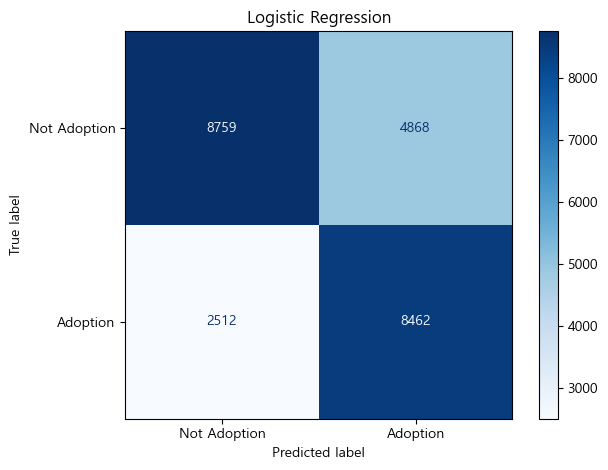

In [38]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Adoption", "Adoption"])
disp.plot(cmap="Blues")
plt.title("Logistic Regression")
plt.tight_layout()
plt.savefig("logreg_confusion_matrix.png", dpi=120)
plt.show()

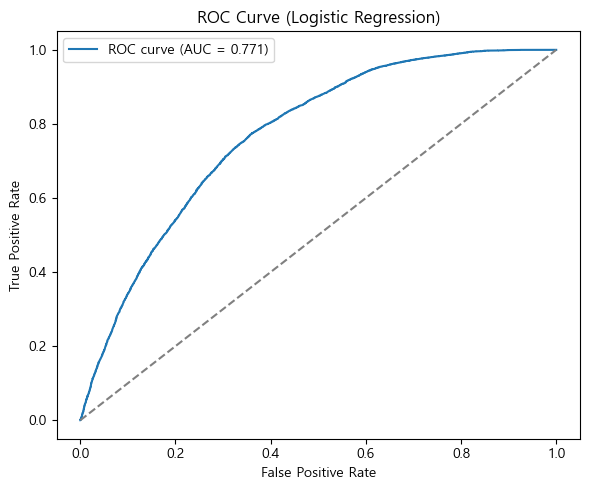

In [39]:
# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc_score(y_test, y_proba):.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Logistic Regression)")
plt.legend()
plt.tight_layout()
plt.savefig("logreg_roc_curve.png", dpi=120)
plt.show()

**Precision-Recall 커브 및 최적 임계값**
- 기본 임계값 0.5 대신, 목적(recall 우선 vs precision 우선)에 맞는 임계값을 탐색

F1 최대화 임계값: 0.435 (F1=0.702)

[최적 임계값 적용 시 성능]
Precision: 0.591
Recall   : 0.866
F1-score : 0.702


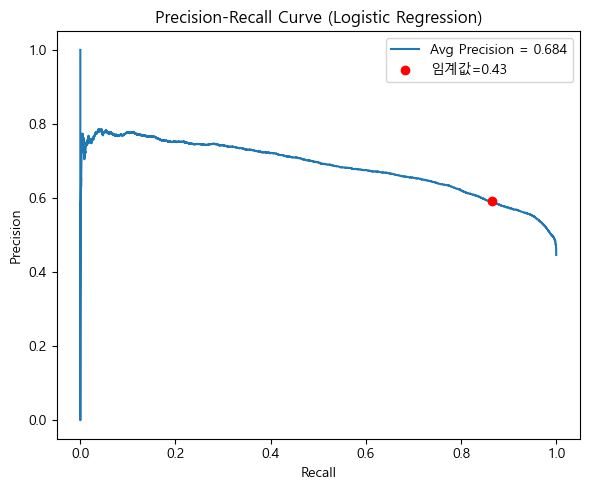

In [40]:
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)
f1_scores = 2 * precisions * recalls / (precisions + recalls + 1e-9)
best_idx = np.argmax(f1_scores[:-1])  # thresholds는 precisions/recalls보다 길이가 1 짧음
best_threshold = thresholds[best_idx]
 
print(f"F1 최대화 임계값: {best_threshold:.3f} (F1={f1_scores[best_idx]:.3f})")
 
y_pred_opt = (y_proba >= best_threshold).astype(int)
print("\n[최적 임계값 적용 시 성능]")
print(f"Precision: {precision_score(y_test, y_pred_opt):.3f}")
print(f"Recall   : {recall_score(y_test, y_pred_opt):.3f}")
print(f"F1-score : {f1_score(y_test, y_pred_opt):.3f}")
 
plt.figure(figsize=(6, 5))
plt.plot(recalls, precisions, label=f"Avg Precision = {average_precision_score(y_test, y_proba):.3f}")
plt.scatter(recalls[best_idx], precisions[best_idx], color="red", zorder=5, label=f"임계값={best_threshold:.2f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (Logistic Regression)")
plt.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / "logreg_pr_curve.png", dpi=120)
plt.show()

**모델 보정 확인**
- 예측 확률이 실제 관측 빈도와 얼마나 일치하는지 확인

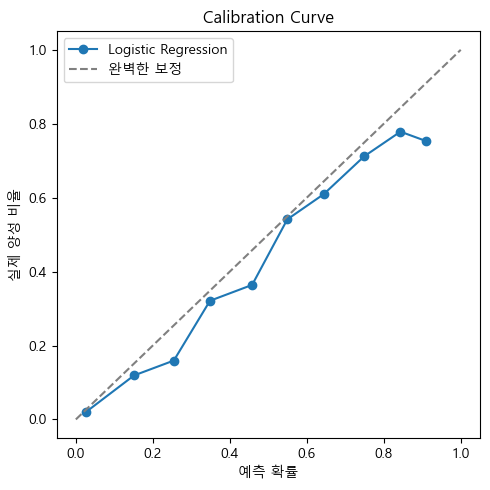

In [41]:
prob_true, prob_pred = calibration_curve(y_test, y_proba, n_bins=10)
 
plt.figure(figsize=(5, 5))
plt.plot(prob_pred, prob_true, marker="o", label="Logistic Regression")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="완벽한 보정")
plt.xlabel("예측 확률")
plt.ylabel("실제 양성 비율")
plt.title("Calibration Curve")
plt.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / "logreg_calibration_curve.png", dpi=120)
plt.show()

**계수 해석**


[영향력 상위 15개 변수 - 계수/오즈비]
                             feature  coefficient  odds_ratio
                Intake Type_Wildlife    -2.663611    0.069696
           Intake Type_Public Assist    -1.702279    0.182268
      Intake Type_Euthanasia Request    -1.659029    0.190324
                         sex_Unknown    -1.590748    0.203773
           sterilized_status_Unknown    -1.590748    0.203773
                   breed_grouped_Bat    -1.141873    0.319220
                            has_name     1.141085    3.130162
               breed_grouped_Bat Mix    -1.034988    0.355231
                        age_group_성체    -0.796780    0.450778
breed_grouped_Domestic Shorthair Mix    -0.753300    0.470810
                       age_group_청년기    -0.730553    0.481642
          breed_grouped_Pit Bull Mix    -0.659270    0.517229
               Intake Condition_Sick    -0.631015    0.532051
    breed_grouped_Domestic Shorthair    -0.623381    0.536129
           breed_grouped_Siamese Mix    -0.6

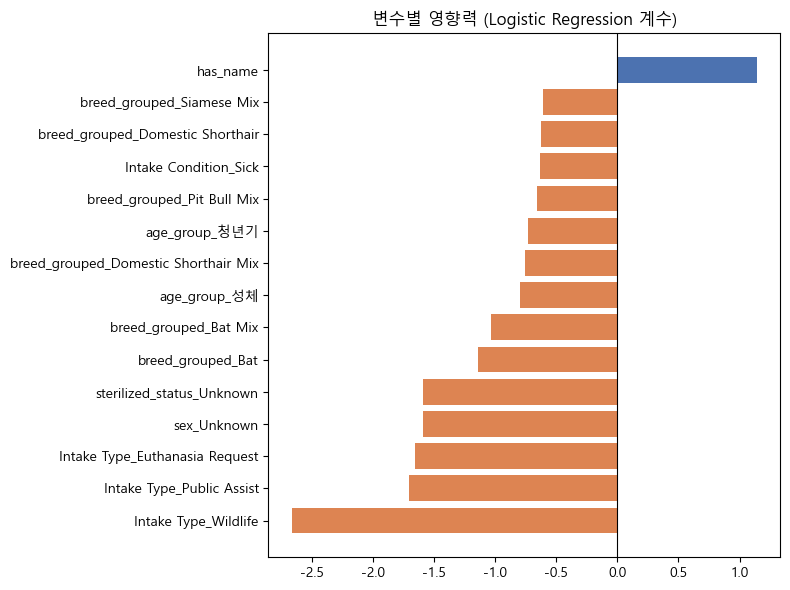

In [ ]:
coef_df = pd.DataFrame({
    "feature": X_train_scaled.columns,
    "coefficient": model.coef_[0],
})
coef_df["odds_ratio"] = np.exp(coef_df["coefficient"])
coef_df = coef_df.reindex(coef_df["coefficient"].abs().sort_values(ascending=False).index)
 
print("\n[영향력 상위 15개 변수 - 계수/오즈비]")
print(coef_df.head(15).to_string(index=False))
 
plt.figure(figsize=(8, 6))
top15 = coef_df.head(15).sort_values("coefficient")
colors = ["#DD8452" if c < 0 else "#4C72B0" for c in top15["coefficient"]]
plt.barh(top15["feature"], top15["coefficient"], color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("변수별 영향력 (Logistic Regression 계수)")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "logreg_coefficients.png", dpi=120)
plt.show()

In [13]:
joblib.dump({"model": model, "scaler": scaler, "numeric_cols": numeric_cols}, "logreg_model.pkl")
print("\n모델 저장 완료: logreg_model.pkl")


모델 저장 완료: logreg_model.pkl
